# Phase-detection walkthrough

This notebook runs the spatio-temporal multi-task phase model on
synthetic data. 

Same code as `python -m src.phase.train --synthetic`and model has three parts:


1. FrameEncoder - what each frame looks like
2. temporal head (TCN) - context over time
3. step head - which surgical step, multi-class
4. instr head - which instruments, multi-label


So each frame of a clip gets a predicted step and a set of predicted instruments.

## 0. Setup

In [1]:
import os, sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

os.environ["PSAI_FORCE_CPU"] = "1"

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.common.device import get_device, device_report

device = get_device()
print(device_report(device))

CPU: everything works but slowly. Fine for the synthetic smoke test only.


## 1. What the data looks like

There are two dataset classes:

- `ClipDataset` reads real frames + labels off disk (PitVis-style).
- `SyntheticClipDataset` makes random clips in memory, for smoke tests.

In [2]:
from src.data.make_dummy_data import make_phase
from src.phase.dataset import ClipDataset

make_phase("data/phase")  # writes videos.json + frame folders

disk_ds = ClipDataset("data/phase", clip_len=16, stride=8, img_size=64, num_instruments=18)
item = disk_ds[0]
print("\none clip from disk:")
for k, v in item.items():
    shape = tuple(v.shape) if torch.is_tensor(v) else v
    print(f"  {k:11s} {shape}")

phase: 2 videos x 40 frames -> data/phase

one clip from disk:
  clip        (16, 3, 64, 64)
  step        (16,)
  instrument  (16, 18)
  video_id    video_00


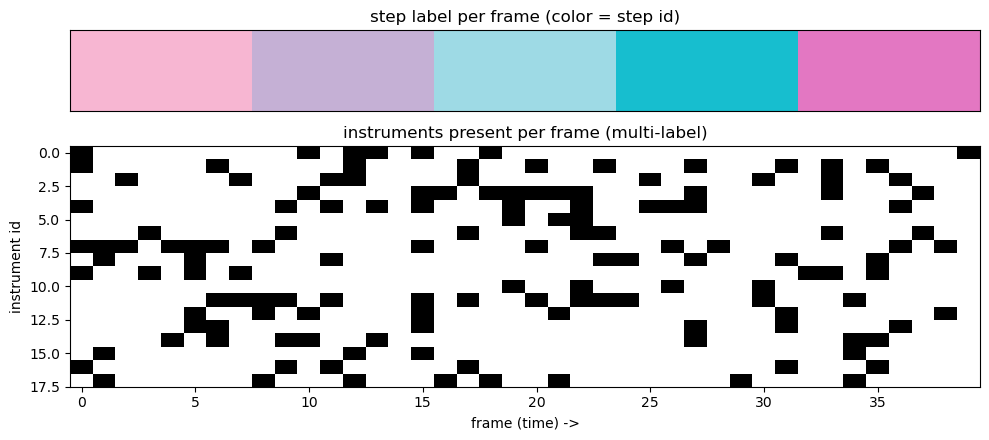

In [3]:
# a longer window so the timeline is easier to read
long_ds = ClipDataset("data/phase", clip_len=40, stride=40, img_size=64, num_instruments=18)
clip = long_ds[0]
steps = clip["step"].numpy()              # [T]
instr = clip["instrument"].numpy().T      # [num_instr, T]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(10, 4.5), gridspec_kw={"height_ratios": [1, 3]})
a0.imshow(steps[None, :], aspect="auto", cmap="tab20", vmin=0, vmax=13)
a0.set_yticks([]); a0.set_xticks([]); a0.set_title("step label per frame (color = step id)")
a1.imshow(instr, aspect="auto", cmap="Greys", interpolation="nearest")
a1.set_xlabel("frame (time) ->"); a1.set_ylabel("instrument id")
a1.set_title("instruments present per frame (multi-label)")
plt.tight_layout()
plt.show()

## 2. Synthetic clips for training

Train on `SyntheticClipDataset`, which is just some random clips with the right
shapes and no disk. The labels here are random (i.e. not piecewise-constant), so
this only proves the loop runs and can fit data; it's not a real result.

In [4]:
from src.phase.dataset import SyntheticClipDataset

NUM_STEPS, NUM_INSTR = 14, 18
train_ds = SyntheticClipDataset(n=8, clip_len=16, img_size=64,
                                num_steps=NUM_STEPS, num_instruments=NUM_INSTR, seed=0)
val_ds = SyntheticClipDataset(n=4, clip_len=16, img_size=64,
                              num_steps=NUM_STEPS, num_instruments=NUM_INSTR, seed=1)
print(f"train: {len(train_ds)} clips | val: {len(val_ds)} clips")
print("clip tensor:", tuple(train_ds[0]["clip"].shape), "  [T, C, H, W]")

train: 8 clips | val: 4 clips
clip tensor: (16, 3, 64, 64)   [T, C, H, W]


## 3. Build the model

`PhaseModelConfig` picks the backbone, temporal head, and label counts. I use a
light `convnext_atto` backbone and a small TCN so it runs fast on CPU. Building it
wires the encoder to the temporal head to the two output heads.

In [5]:
from src.phase.model import SpatioTemporalMultiTask, PhaseModelConfig
from src.common.lora import count_trainable

cfg = PhaseModelConfig(
    backbone="timm:convnext_atto", pretrained=False,
    temporal="tcn", temporal_ch=64, temporal_layers=3,
    num_steps=NUM_STEPS, num_instruments=NUM_INSTR,
)
model = SpatioTemporalMultiTask(cfg).to(device)

trainable, total = count_trainable(model)
print(f"params: {total/1e6:.2f}M total | {trainable/1e6:.2f}M trainable")
print("\nmodel parts:")
for name, _ in model.named_children():
    print("  -", name)

params: 3.45M total | 3.45M trainable

model parts:
  - encoder
  - temporal
  - step_head
  - instr_head


## 4. One forward pass

In [6]:
batch_clip = torch.stack([train_ds[i]["clip"] for i in range(2)]).to(device)
batch_step = torch.stack([train_ds[i]["step"] for i in range(2)]).to(device)
batch_instr = torch.stack([train_ds[i]["instrument"] for i in range(2)]).to(device)

model.eval()
with torch.no_grad():
    out = model(batch_clip)
print("step logits:", tuple(out["step"].shape))
print("instr logits:", tuple(out["instrument"].shape))

loss, parts = model.compute_loss(out, batch_step, batch_instr)
print(f"\nloss {loss.item():.3f}  (step {parts['step']:.3f} + instrument {parts['instrument']:.3f})")

step logits: (2, 16, 14)
instr logits: (2, 16, 18)

loss 3.450  (step 2.742 + instrument 0.708)


## 5. Training

In [7]:
from torch.utils.data import DataLoader
from src.phase.eval import macro_f1_multiclass, macro_f1_multilabel

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False)
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)

@torch.no_grad()
def step_f1(loader):
    model.eval()
    logits, targets = [], []
    for b in loader:
        logits.append(model(b["clip"].to(device))["step"].cpu())
        targets.append(b["step"])
    return macro_f1_multiclass(torch.cat(logits), torch.cat(targets), NUM_STEPS)

EPOCHS = 12
hist = {"loss": [], "train_f1": [], "val_f1": []}
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for b in train_loader:
        out = model(b["clip"].to(device))
        loss, _ = model.compute_loss(out, b["step"].to(device), b["instrument"].to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    tr_f1, va_f1 = step_f1(train_loader), step_f1(val_loader)
    hist["loss"].append(running / len(train_loader))
    hist["train_f1"].append(tr_f1); hist["val_f1"].append(va_f1)
    print(f"epoch {epoch:02d} | loss {hist['loss'][-1]:.3f} | "
          f"train F1 {tr_f1:.3f} | val F1 {va_f1:.3f}")

epoch 00 | loss 3.435 | train F1 0.871 | val F1 0.067
epoch 01 | loss 1.339 | train F1 1.000 | val F1 0.083
epoch 02 | loss 0.801 | train F1 1.000 | val F1 0.098
epoch 03 | loss 0.651 | train F1 1.000 | val F1 0.091
epoch 04 | loss 0.565 | train F1 1.000 | val F1 0.061
epoch 05 | loss 0.506 | train F1 1.000 | val F1 0.062
epoch 06 | loss 0.451 | train F1 1.000 | val F1 0.068
epoch 07 | loss 0.401 | train F1 1.000 | val F1 0.060
epoch 08 | loss 0.358 | train F1 1.000 | val F1 0.060
epoch 09 | loss 0.315 | train F1 1.000 | val F1 0.058
epoch 10 | loss 0.271 | train F1 1.000 | val F1 0.046
epoch 11 | loss 0.230 | train F1 1.000 | val F1 0.062


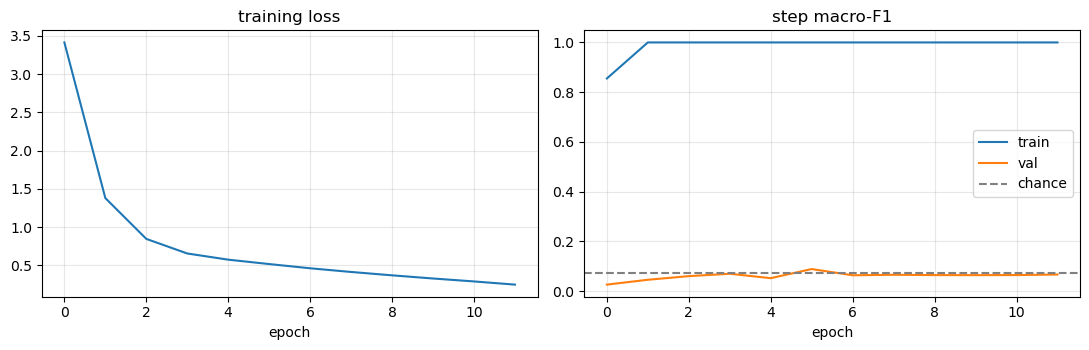

In [8]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3.6))
a0.plot(hist["loss"]); a0.set_title("training loss")
a0.set_xlabel("epoch"); a0.grid(alpha=0.3)
a1.plot(hist["train_f1"], label="train"); a1.plot(hist["val_f1"], label="val")
a1.axhline(1 / NUM_STEPS, ls="--", c="gray", label="chance")
a1.set_title("step macro-F1"); a1.set_xlabel("epoch"); a1.legend(); a1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Predicted timelines

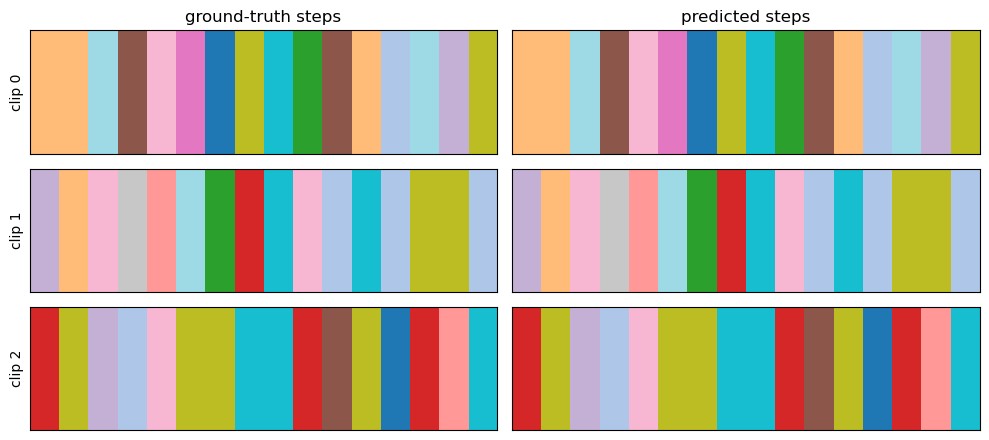

In [9]:
model.eval()
fig, axes = plt.subplots(3, 2, figsize=(10, 4.5))
with torch.no_grad():
    for i in range(3):
        clip = train_ds[i]["clip"].unsqueeze(0).to(device)
        gt = train_ds[i]["step"].numpy()
        pred = model(clip)["step"][0].argmax(-1).cpu().numpy()
        axes[i, 0].imshow(gt[None, :], aspect="auto", cmap="tab20", vmin=0, vmax=NUM_STEPS - 1)
        axes[i, 1].imshow(pred[None, :], aspect="auto", cmap="tab20", vmin=0, vmax=NUM_STEPS - 1)
        for j in range(2):
            axes[i, j].set_yticks([]); axes[i, j].set_xticks([])
        axes[i, 0].set_ylabel(f"clip {i}")
axes[0, 0].set_title("ground-truth steps")
axes[0, 1].set_title("predicted steps")
plt.tight_layout()
plt.show()

In [10]:
# the instrument head too (multi-label macro-F1 on the train set)
with torch.no_grad():
    logits = torch.cat([model(b["clip"].to(device))["instrument"].cpu() for b in train_loader])
    targets = torch.cat([b["instrument"] for b in train_loader])
print(f"train instrument macro-F1: {macro_f1_multilabel(logits, targets):.3f}")

train instrument macro-F1: 0.409


## 7. Save a checkpoint

In [11]:
os.makedirs("runs/phase", exist_ok=True)
torch.save({"model": model.state_dict(), "cfg": vars(cfg)}, "runs/phase/best.pt")
ckpt = torch.load("runs/phase/best.pt", weights_only=False)
print("saved runs/phase/best.pt")
print("keys:", list(ckpt.keys()), "| tensors:", len(ckpt["model"]))

saved runs/phase/best.pt
keys: ['model', 'cfg'] | tensors: 144
